In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
from matplotlib import pyplot as plt
from matplotlib import cm
import metpy.calc as mpcalc

%matplotlib inline

class test

In [2]:
sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
sst = sst.sel(time = slice('1990', '2020')) 
sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 372, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [3]:
# select time and domain
ds_EP = sst.sel(lat = slice(50, -50), lon = slice(190, 240))
ds_EP_mean = ds_EP.mean(dim = ('lon'))
ds_EP_mean

<xarray.Dataset>
Dimensions:    (lat: 51, time: 372, nbnds: 2)
Coordinates:
  * lat        (lat) float32 50.0 48.0 46.0 44.0 ... -44.0 -46.0 -48.0 -50.0
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat) float32 6.677 7.541 8.676 10.0 ... 11.51 10.52 9.619

In [4]:
# select time
vtimes = ds_EP_mean.time.values.astype('datetime64[ms]').astype('O')

# select latitude
lats = ds_EP_mean.lat.values

Text(1.0, 1.0, 'Time Range: 19900101 00Z - 20201201 00Z')

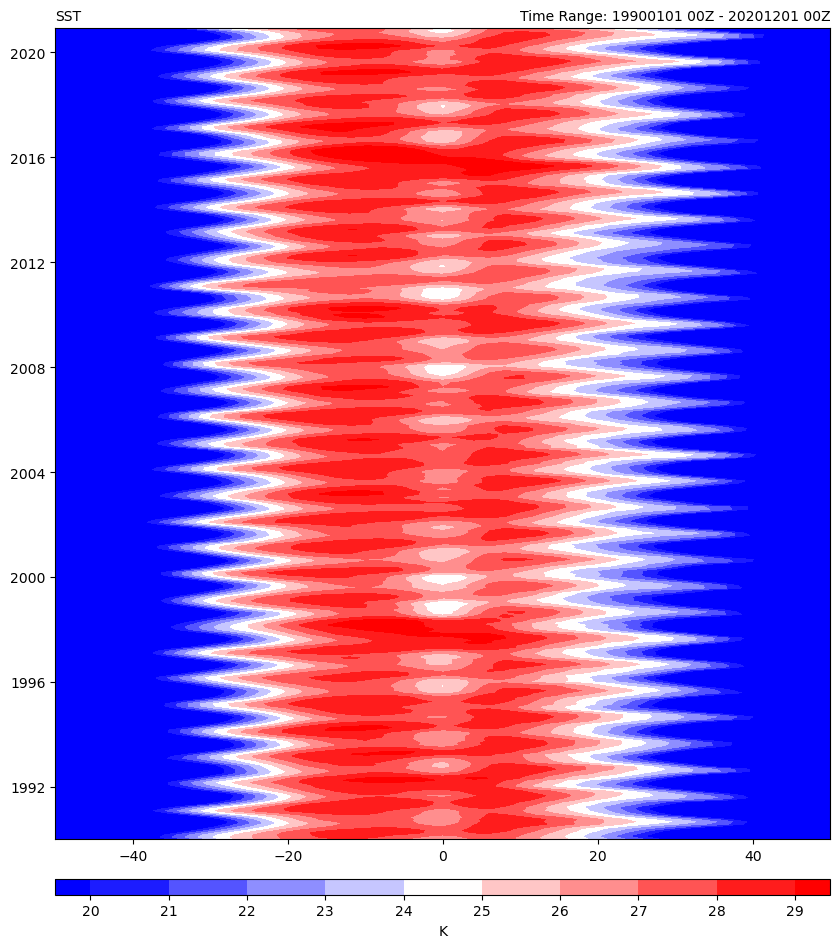

In [5]:
fig = plt.figure(figsize=(10, 13))

ax = fig.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(20, 30, 1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf = ax.contourf(lats, vtimes, ds_EP_mean['sst'], clevs, cmap=plt.cm.bwr, extend='both')
cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
cbar.set_label('K')
#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

plt.title('SST', loc='left', fontsize=10)
plt.title('Time Range: {0:%Y%m%d %HZ} - {1:%Y%m%d %HZ}'.format(vtimes[0], vtimes[-1]),
          loc='right', fontsize=10)

In [6]:
ds1 = ds_EP_mean.transpose()  #此部分轉至，因為緯度在左側比較直覺
ds1

<xarray.Dataset>
Dimensions:    (lat: 51, time: 372, nbnds: 2)
Coordinates:
  * lat        (lat) float32 50.0 48.0 46.0 44.0 ... -44.0 -46.0 -48.0 -50.0
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (nbnds, time) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (lat, time) float32 6.677 5.569 5.605 6.266 ... 7.999 8.592 9.619

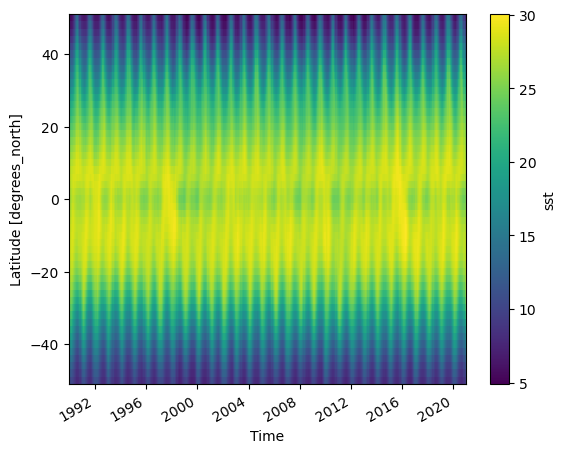

In [7]:
ds1['sst'].plot()

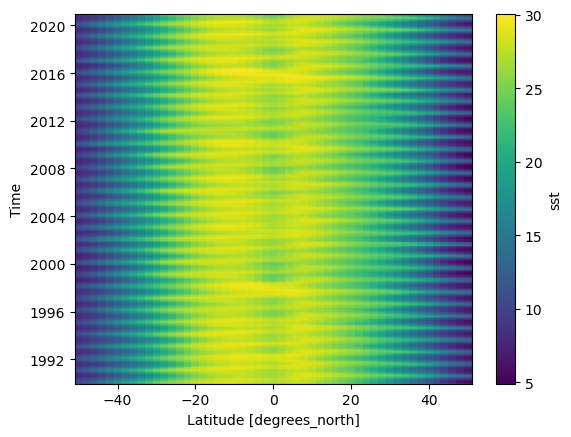

In [8]:
ds_EP_mean['sst'].plot()

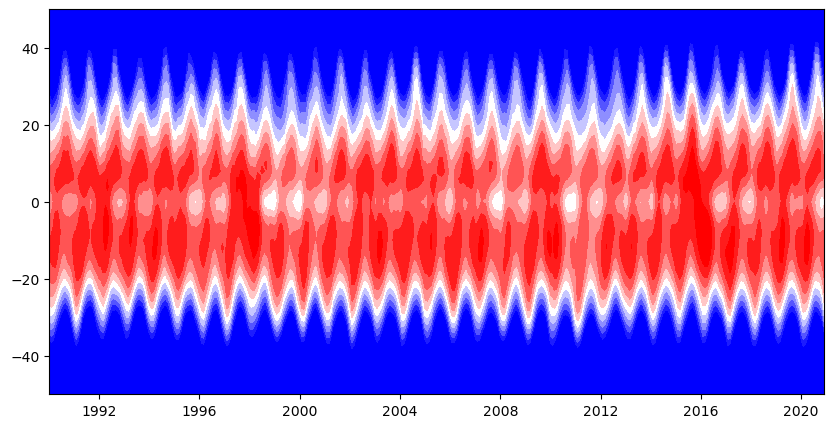

In [9]:
fig1 = plt.figure(figsize=(10, 5))

ax1 = fig1.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(20, 30, 1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf1 = ax1.contourf(vtimes, lats, ds1['sst'], clevs, cmap=plt.cm.bwr, extend='both')
#cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
#cbar.set_label('K')

#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

#plt.title('SST', loc='left', fontsize=10)

# Exercise 2-1 (original domain)

Taiwan

In [10]:
# load precipitation data
prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
prec = prec.sel(time = slice('1990', '2020')) 
prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.02212 0.01551 ... 0.2608 0.2638
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

In [11]:
# select time and domain
prec_ta = prec.sel(lat = slice(20, 26), lon=slice(118, 125))
prec_ta_mean = prec_ta.mean(dim = ('lon'))
prec_ta_mean

<xarray.Dataset>
Dimensions:    (lat: 2, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 21.25 23.75
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (lat, nv) float32 20.0 22.5 22.5 25.0
    lon_bnds   (nv) float32 120.0 122.5
    precip     (time, lat) float32 1.633 2.903 2.071 4.442 ... 2.17 1.622 1.974

In [12]:
# select time
vtimes = prec_ta_mean.time.values.astype('datetime64[ms]').astype('O')

# select latitude
lats = prec_ta_mean.lat.values

In [13]:
#圖看起來很怪，原因可能是範圍跨度太小

Text(1.0, 1.0, 'Time Range: 19900101 00Z - 20201201 00Z')

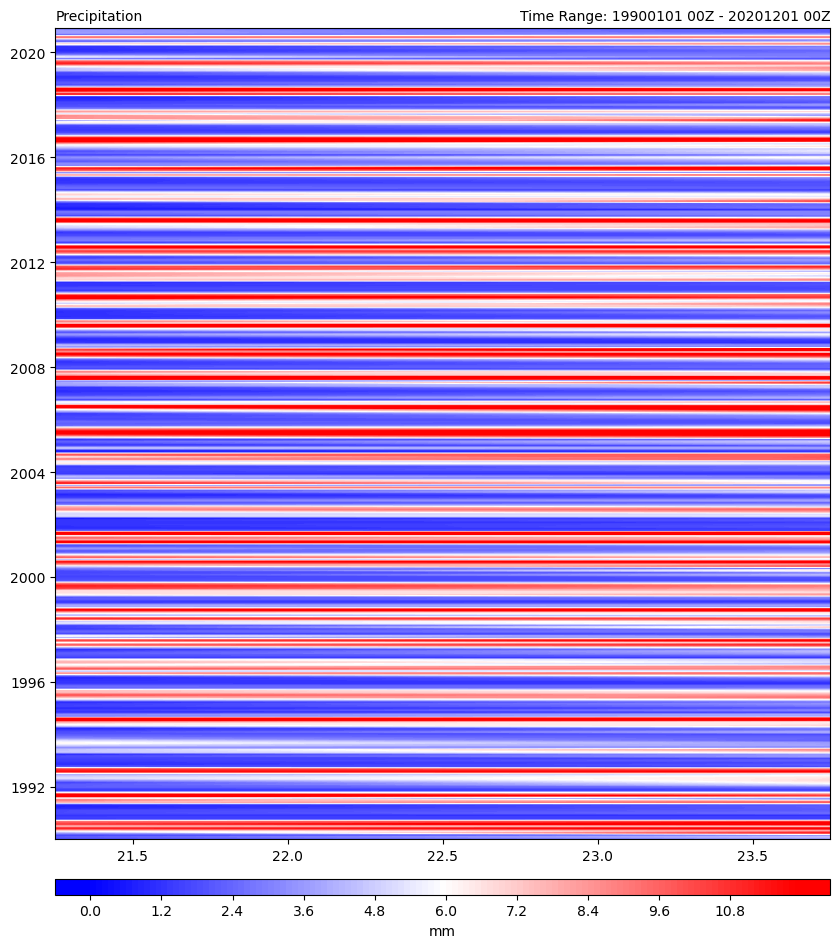

In [14]:
fig = plt.figure(figsize=(10, 13))

ax = fig.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 12, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf = ax.contourf(lats, vtimes, prec_ta_mean['precip'], clevs, cmap=plt.cm.bwr, extend='both')
cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
cbar.set_label('mm')
#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

plt.title('Precipitation', loc='left', fontsize=10)
plt.title('Time Range: {0:%Y%m%d %HZ} - {1:%Y%m%d %HZ}'.format(vtimes[0], vtimes[-1]),
          loc='right', fontsize=10)

In [15]:
ds1 = prec_ta_mean.transpose()  #此部分轉至，因為緯度在左側比較直覺
ds1

<xarray.Dataset>
Dimensions:    (lat: 2, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 21.25 23.75
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (nv, time) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (nv, lat) float32 20.0 22.5 22.5 25.0
    lon_bnds   (nv) float32 120.0 122.5
    precip     (lat, time) float32 1.633 2.071 1.339 3.647 ... 2.189 2.17 1.974

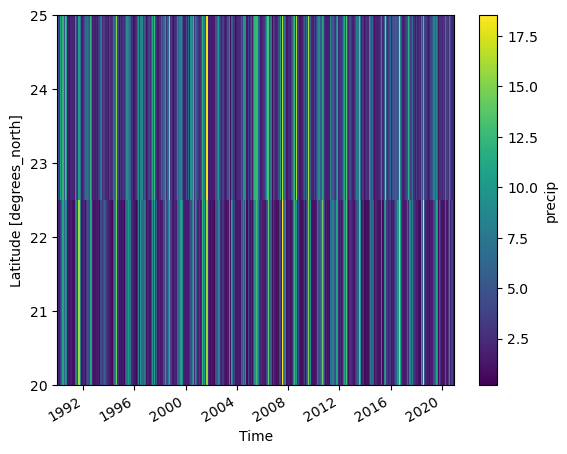

In [16]:
ds1['precip'].plot()

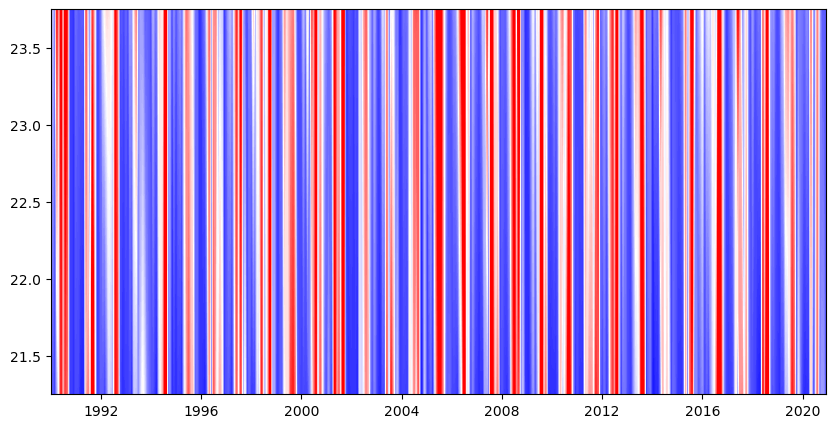

In [17]:
fig1 = plt.figure(figsize=(10, 5))

ax1 = fig1.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 12, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf1 = ax1.contourf(vtimes, lats, ds1['precip'], clevs, cmap=plt.cm.bwr, extend='both')
#cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
#cbar.set_label('K')

#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

#plt.title('SST', loc='left', fontsize=10)

Melbourn

In [18]:
# select time and domain
prec_mel = prec.sel(lat = slice(-40, -30), lon=slice(140, 150))
prec_mel_mean = prec_mel.mean(dim = ('lon'))
prec_mel_mean

<xarray.Dataset>
Dimensions:    (lat: 4, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 -38.75 -36.25 -33.75 -31.25
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (lat, nv) float32 -40.0 -37.5 -37.5 -35.0 -35.0 -32.5 -32.5 -30.0
    lon_bnds   (nv) float32 143.8 146.2
    precip     (time, lat) float32 0.3801 0.677 0.8507 ... 1.253 1.033 1.674

In [19]:
# select time
vtimes = prec_mel_mean.time.values.astype('datetime64[ms]').astype('O')

# select latitude
lats = prec_mel_mean.lat.values

Text(1.0, 1.0, 'Time Range: 19900101 00Z - 20201201 00Z')

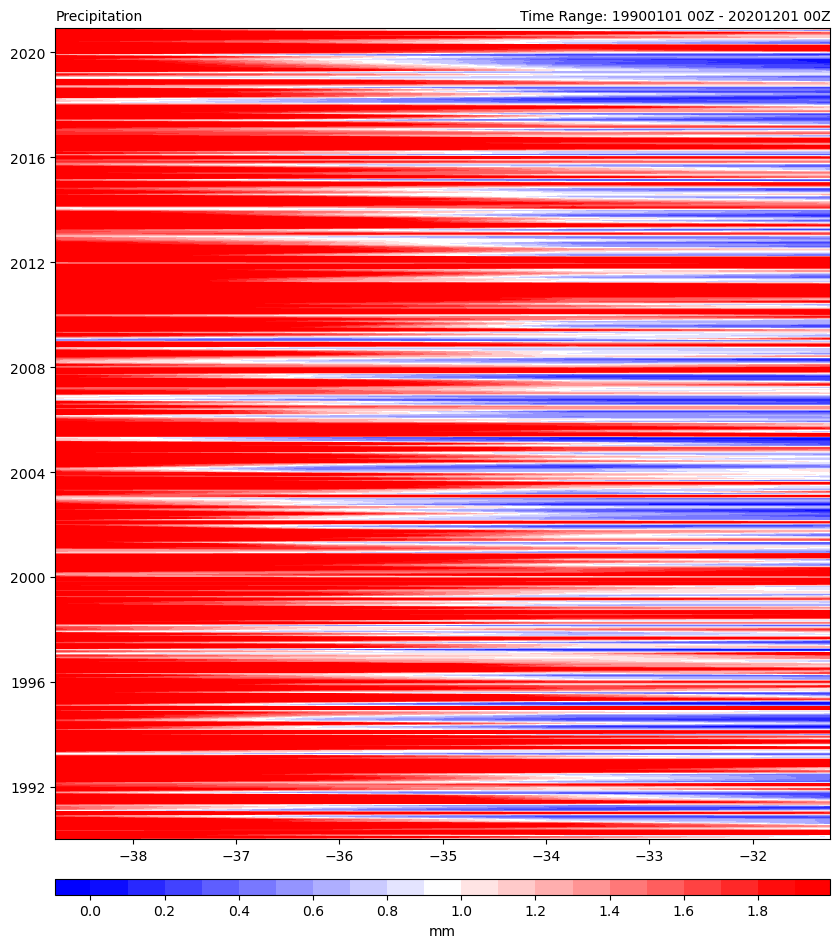

In [20]:
fig = plt.figure(figsize=(10, 13))

ax = fig.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 2, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf = ax.contourf(lats, vtimes, prec_mel_mean['precip'], clevs, cmap=plt.cm.bwr, extend='both')
cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
cbar.set_label('mm')
#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

plt.title('Precipitation', loc='left', fontsize=10)
plt.title('Time Range: {0:%Y%m%d %HZ} - {1:%Y%m%d %HZ}'.format(vtimes[0], vtimes[-1]),
          loc='right', fontsize=10)

In [21]:
ds2 = prec_mel_mean.transpose()  #此部分轉至，因為緯度在左側比較直覺
ds2

<xarray.Dataset>
Dimensions:    (lat: 4, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 -38.75 -36.25 -33.75 -31.25
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (nv, time) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (nv, lat) float32 -40.0 -37.5 -35.0 -32.5 -37.5 -35.0 -32.5 -30.0
    lon_bnds   (nv) float32 143.8 146.2
    precip     (lat, time) float32 0.3801 3.521 1.458 ... 1.57 0.2046 1.674

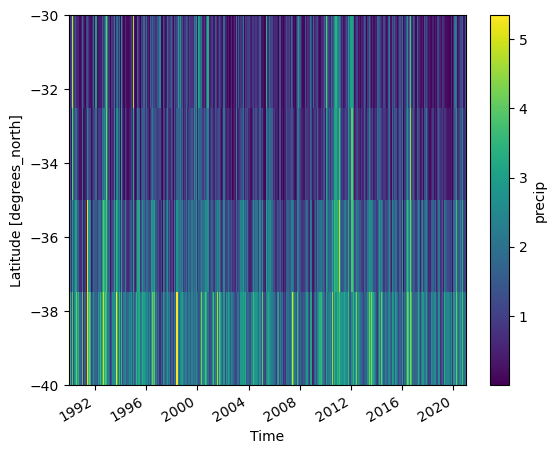

In [22]:
ds2['precip'].plot()

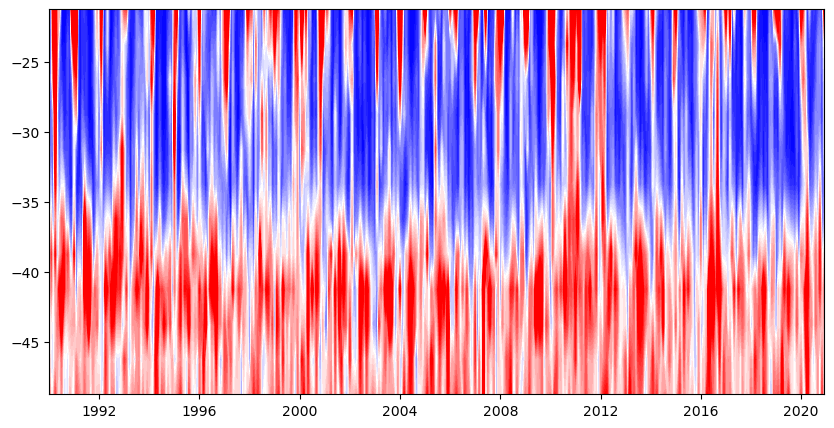

In [38]:
fig1 = plt.figure(figsize=(10, 5))

ax1 = fig1.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 4, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf1 = ax1.contourf(vtimes, lats, ds2['precip'], clevs, cmap=plt.cm.bwr, extend='both')
#cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
#cbar.set_label('K')

#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

#plt.title('SST', loc='left', fontsize=10)

# Exercice 2-2 (new domain)

In [24]:
# select time and domain
prec_ta = prec.sel(lat = slice(10, 40), lon = slice(118, 125))
prec_ta_mean = prec_ta.mean(dim = ('lon'))
prec_ta_mean

<xarray.Dataset>
Dimensions:    (lat: 12, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 11.25 13.75 16.25 18.75 ... 31.25 33.75 36.25 38.75
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (lat, nv) float32 10.0 12.5 12.5 15.0 ... 35.0 37.5 37.5 40.0
    lon_bnds   (nv) float32 120.0 122.5
    precip     (time, lat) float32 2.197 3.04 1.429 ... 0.9059 0.5063 0.2087

In [25]:
# select time
vtimes = prec_ta_mean.time.values.astype('datetime64[ms]').astype('O')

# select latitude
lats = prec_ta_mean.lat.values

Text(1.0, 1.0, 'Time Range: 19900101 00Z - 20201201 00Z')

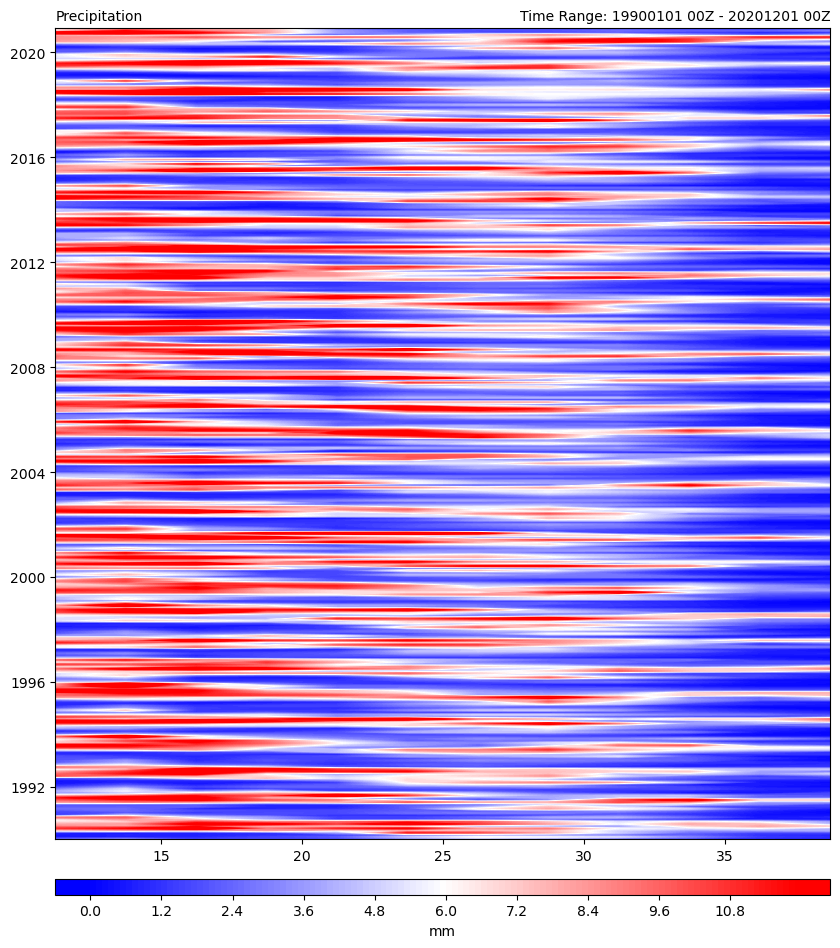

In [26]:
fig = plt.figure(figsize=(10, 13))

ax = fig.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 12, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf = ax.contourf(lats, vtimes, prec_ta_mean['precip'], clevs, cmap=plt.cm.bwr, extend='both')
cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
cbar.set_label('mm')
#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

plt.title('Precipitation', loc='left', fontsize=10)
plt.title('Time Range: {0:%Y%m%d %HZ} - {1:%Y%m%d %HZ}'.format(vtimes[0], vtimes[-1]),
          loc='right', fontsize=10)

In [27]:
ds1 = prec_ta_mean.transpose()  #此部分轉至，因為緯度在左側比較直覺
ds1

<xarray.Dataset>
Dimensions:    (lat: 12, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 11.25 13.75 16.25 18.75 ... 31.25 33.75 36.25 38.75
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (nv, time) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (nv, lat) float32 10.0 12.5 15.0 17.5 ... 32.5 35.0 37.5 40.0
    lon_bnds   (nv) float32 120.0 122.5
    precip     (lat, time) float32 2.197 0.6062 0.4097 ... 0.725 2.85 0.2087

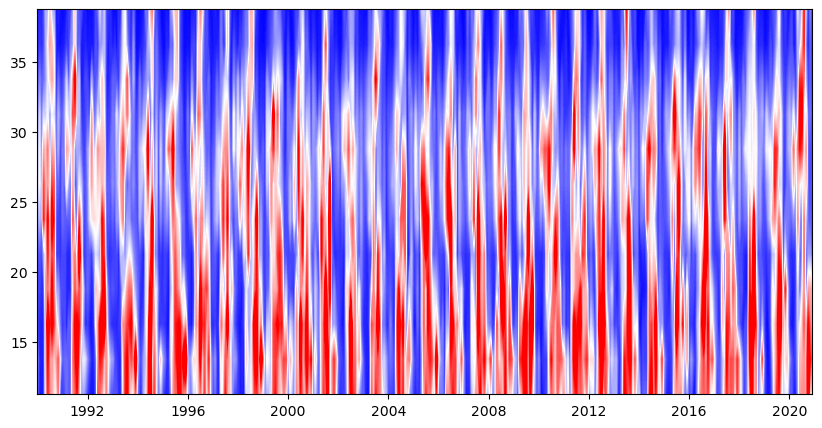

In [28]:
fig1 = plt.figure(figsize=(10, 5))

ax1 = fig1.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 12, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf1 = ax1.contourf(vtimes, lats, ds1['precip'], clevs, cmap=plt.cm.bwr, extend='both')
#cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
#cbar.set_label('K')

#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

#plt.title('SST', loc='left', fontsize=10)

Melbourne

In [29]:
# select time and domain
prec_mel = prec.sel(lat = slice(-50, -20), lon=slice(140, 150))
prec_mel_mean = prec_mel.mean(dim = ('lon'))
prec_mel_mean

<xarray.Dataset>
Dimensions:    (lat: 12, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 -48.75 -46.25 -43.75 ... -26.25 -23.75 -21.25
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (lat, nv) float32 -50.0 -47.5 -47.5 -45.0 ... -22.5 -22.5 -20.0
    lon_bnds   (nv) float32 143.8 146.2
    precip     (time, lat) float32 3.22 2.582 1.777 1.535 ... 1.674 1.99 4.024

In [30]:
# select time
vtimes = prec_mel_mean.time.values.astype('datetime64[ms]').astype('O')

# select latitude
lats = prec_mel_mean.lat.values

Text(1.0, 1.0, 'Time Range: 19900101 00Z - 20201201 00Z')

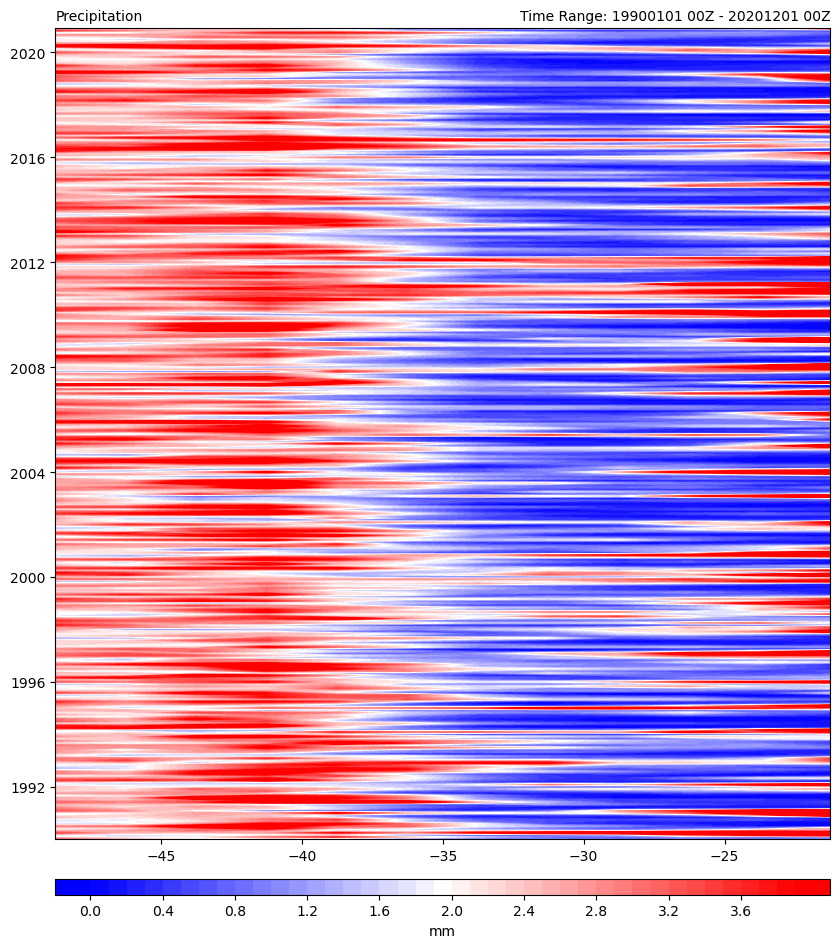

In [36]:
fig = plt.figure(figsize=(10, 13))

ax = fig.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 4, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf = ax.contourf(lats, vtimes, prec_mel_mean['precip'], clevs, cmap=plt.cm.bwr, extend='both')
cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
cbar.set_label('mm')
#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

plt.title('Precipitation', loc='left', fontsize=10)
plt.title('Time Range: {0:%Y%m%d %HZ} - {1:%Y%m%d %HZ}'.format(vtimes[0], vtimes[-1]),
          loc='right', fontsize=10)

In [32]:
ds2 = prec_mel_mean.transpose()  #此部分轉至，因為緯度在左側比較直覺
ds2

<xarray.Dataset>
Dimensions:    (lat: 12, time: 372, nv: 2)
Coordinates:
  * lat        (lat) float32 -48.75 -46.25 -43.75 ... -26.25 -23.75 -21.25
  * time       (time) datetime64[ns] 1990-01-01 1990-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (nv, time) datetime64[ns] 1990-01-01 1990-02-01 ... 2021-01-01
    lat_bnds   (nv, lat) float32 -50.0 -47.5 -45.0 -42.5 ... -25.0 -22.5 -20.0
    lon_bnds   (nv) float32 143.8 146.2
    precip     (lat, time) float32 3.22 1.946 2.097 ... 0.8341 0.3764 4.024

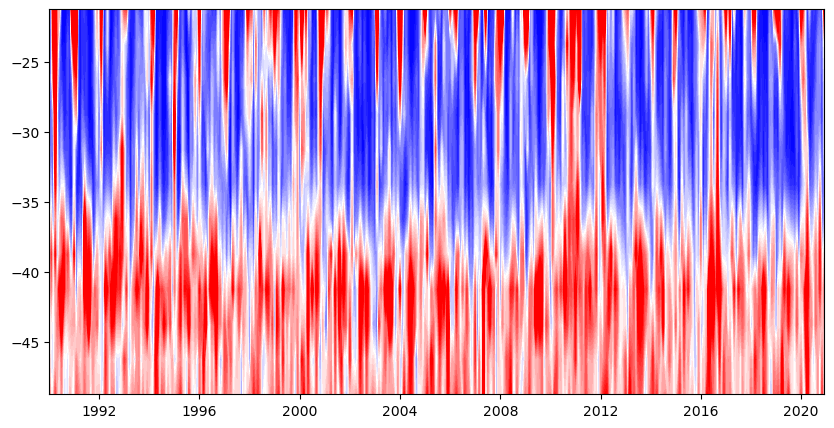

In [37]:
fig1 = plt.figure(figsize=(10, 5))

ax1 = fig1.add_subplot(111)
#ax.invert_yaxis()  # invert time

clevs = np.arange(0, 4, 0.1)

#smoothed
#cf = ax.contourf(lats, vtimes, mpcalc.smooth_n_point(ds_EP_mean['sst'], 9, 2), clevs, cmap=plt.cm.bwr, extend='both')

#not smoothed
cf1 = ax1.contourf(vtimes, lats, ds2['precip'], clevs, cmap=plt.cm.bwr, extend='both')
#cbar = plt.colorbar(cf, orientation='horizontal', pad=0.04, aspect=50, extendrect=True)
#cbar.set_label('K')

#ax.set_yticks(vtimes[4::8])
#ax.set_yticklabels(vtimes[4::8])

#plt.title('SST', loc='left', fontsize=10)